# Medium Q2 — 中亞鹹海 (Aral Sea) 水體萎縮分析 (1984–2023)

## 分析策略

結合兩個互補資料集：

| 資料集 | 用途 |
|--------|------|
| JRC Global Surface Water (`JRC/GSW1_4/GlobalSurfaceWater`) | 長期（1984–2021）水體出現頻率統計，30m 解析度，已經品質控制 |
| Landsat 5/7/8/9 SR | 自訂代表年份水體範圍，用 MNDWI 提取，覆蓋至 2023 年 |

代表年份選擇：1984、1990、2000、2010、2015、2020、2023（展示逐步縮小與南北分裂）

## 1. 環境設定

In [ ]:
import ee
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap

# ee.Authenticate()
ee.Initialize(project='0')

## 2. 定義研究區域

In [2]:
# 鹹海完整範圍（含南北分裂後的殘餘部分）
aral_sea_bbox = ee.Geometry.Rectangle([57.5, 42.5, 62.5, 47.0])

SCALE_M    = 500    # 500m 用於面積計算（兼顧精度與速度）
TARGET_CRS = 'EPSG:4326'

# 代表年份
YEARS = [1984, 1990, 2000, 2010, 2015, 2020, 2023]

print('研究區域面積 (km²):', aral_sea_bbox.area(1).divide(1e6).getInfo())

研究區域面積 (km²): 197460.19180096954


## 3. 方法 A：JRC 全球地表水年度統計（1984–2021）

In [3]:
# JRC yearlyHistory：每年每月是否有水體紀錄，2=permanent, 1=seasonal, 0=no water
jrc_yearly = ee.ImageCollection('JRC/GSW1_4/YearlyHistory')

def get_jrc_water_area(year):
    """從 JRC yearly history 取得指定年份的水體面積 (km²)。"""
    img = jrc_yearly.filter(ee.Filter.eq('year', year)).first()
    # 1=seasonal water, 2=permanent water，合併視為有水
    water_mask = img.gte(1).selfMask()
    area_img   = water_mask.multiply(ee.Image.pixelArea()).rename('area')
    total_area = area_img.reduceRegion(
        reducer=ee.Reducer.sum(),
        geometry=aral_sea_bbox,
        scale=SCALE_M,
        maxPixels=int(1e9)
    ).getNumber('area').divide(1e6)  # m² → km²
    return total_area


# 取 1984–2021 每年面積
jrc_years = list(range(1984, 2022))
jrc_areas = [get_jrc_water_area(y).getInfo() for y in jrc_years]

df_jrc = pd.DataFrame({'year': jrc_years, 'area_km2': jrc_areas})
print(df_jrc.head(10))

   year      area_km2
0  1984  45088.809679
1  1985  47236.910089
2  1986  70419.512979
3  1987  72270.647952
4  1988      0.000000
5  1989  67293.337391
6  1990  58885.304066
7  1991  69778.191071
8  1992  69001.466509
9  1993  71226.711980


## 4. 方法 B：Landsat MNDWI 水體提取（代表年份）

In [4]:
def get_landsat_collection(year):
    """依年份選擇合適的 Landsat 衛星並套用 scale factor + 雲遮罩。"""
    start = f'{year}-06-01'
    end   = f'{year}-10-01'  # 夏季（6–9月）雲量少，水體輪廓清晰

    def mask_l57(image):
        qa   = image.select('QA_PIXEL')
        good = qa.bitwiseAnd(0b11111).eq(0)
        return (image.updateMask(good)
                .multiply(0.0000275).add(-0.2)
                .copyProperties(image, ['system:time_start']))

    def mask_l89(image):
        qa   = image.select('QA_PIXEL')
        good = qa.bitwiseAnd(0b11111).eq(0)
        return (image.updateMask(good)
                .multiply(0.0000275).add(-0.2)
                .copyProperties(image, ['system:time_start']))

    if year <= 1999:
        col = (ee.ImageCollection('LANDSAT/LT05/C02/T1_L2')
               .filterDate(start, end)
               .filterBounds(aral_sea_bbox)
               .map(mask_l57))
        green_band, swir_band = 'SR_B2', 'SR_B5'
    elif year <= 2013:
        col = (ee.ImageCollection('LANDSAT/LE07/C02/T1_L2')
               .filterDate(start, end)
               .filterBounds(aral_sea_bbox)
               .map(mask_l57))
        green_band, swir_band = 'SR_B2', 'SR_B5'
    elif year <= 2022:
        col = (ee.ImageCollection('LANDSAT/LC08/C02/T1_L2')
               .filterDate(start, end)
               .filterBounds(aral_sea_bbox)
               .map(mask_l89))
        green_band, swir_band = 'SR_B3', 'SR_B6'
    else:
        col = (ee.ImageCollection('LANDSAT/LC09/C02/T1_L2')
               .filterDate(start, end)
               .filterBounds(aral_sea_bbox)
               .map(mask_l89))
        green_band, swir_band = 'SR_B3', 'SR_B6'

    composite = col.median().clip(aral_sea_bbox)
    # MNDWI = (Green - SWIR) / (Green + SWIR)
    mndwi = composite.normalizedDifference([green_band, swir_band]).rename('MNDWI')
    return mndwi


def extract_water_area_mndwi(year, threshold=0.0):
    """MNDWI > threshold 視為水體，計算面積 (km²)。"""
    mndwi      = get_landsat_collection(year)
    water_mask = mndwi.gt(threshold).selfMask()
    area_img   = water_mask.multiply(ee.Image.pixelArea()).rename('area')
    total_area = area_img.reduceRegion(
        reducer=ee.Reducer.sum(),
        geometry=aral_sea_bbox,
        scale=SCALE_M,
        maxPixels=int(1e9)
    ).getNumber('area').divide(1e6)
    return water_mask, total_area


# 計算各代表年份面積
ls_areas = {}
ls_masks = {}
for yr in YEARS:
    mask, area = extract_water_area_mndwi(yr)
    ls_masks[yr] = mask
    ls_areas[yr] = area.getInfo()
    print(f'  {yr}: {ls_areas[yr]:.1f} km²')

df_ls = pd.DataFrame({'year': list(ls_areas.keys()), 'area_km2': list(ls_areas.values())})

  1984: 15617.4 km²
  1990: 42731.8 km²
  2000: 32824.5 km²
  2010: 26052.4 km²
  2015: 19051.0 km²
  2020: 14292.1 km²
  2023: 11447.5 km²


## 5. 水體面積隨時間變化折線圖

/tmp/ipykernel_373604/842977097.py:18: UserWarning: Glyph 24180 (\N{CJK UNIFIED IDEOGRAPH-5E74}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_373604/842977097.py:18: UserWarning: Glyph 20221 (\N{CJK UNIFIED IDEOGRAPH-4EFD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_373604/842977097.py:18: UserWarning: Glyph 27700 (\N{CJK UNIFIED IDEOGRAPH-6C34}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_373604/842977097.py:18: UserWarning: Glyph 39636 (\N{CJK UNIFIED IDEOGRAPH-9AD4}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_373604/842977097.py:18: UserWarning: Glyph 38754 (\N{CJK UNIFIED IDEOGRAPH-9762}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_373604/842977097.py:18: UserWarning: Glyph 31309 (\N{CJK UNIFIED IDEOGRAPH-7A4D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_373604/842977097.py:18: UserWarning: Glyph 20013 (\N{CJK UNIFIED IDEOGRAP

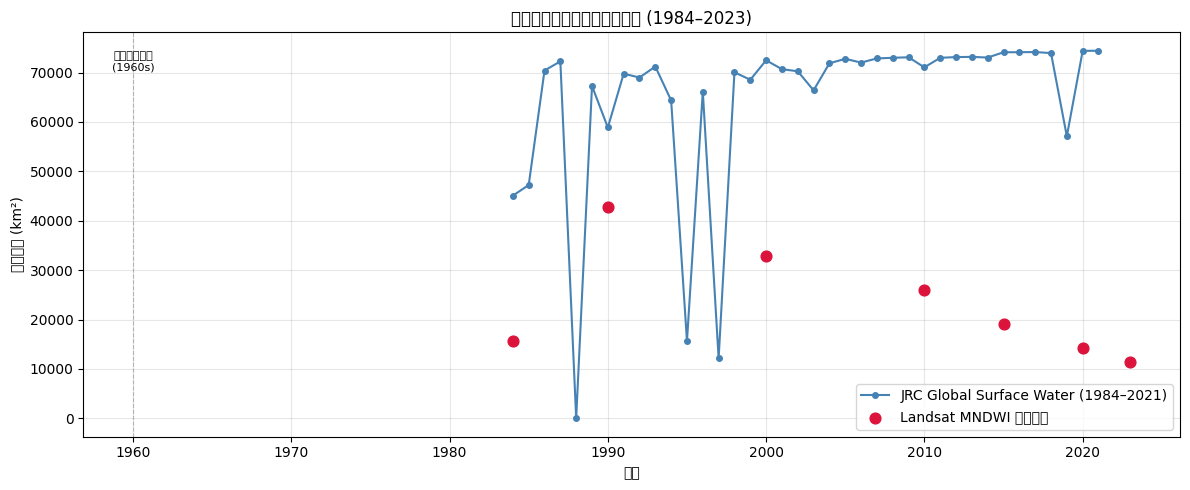

In [5]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(df_jrc['year'], df_jrc['area_km2'], 'o-', color='steelblue',
        lw=1.5, ms=4, label='JRC Global Surface Water (1984–2021)')
ax.scatter(df_ls['year'], df_ls['area_km2'], color='crimson', zorder=5,
           label='Landsat MNDWI 代表年份', s=60)

# 標記關鍵事件
ax.axvline(1960, color='gray', ls='--', lw=0.8, alpha=0.5)
ax.text(1960, ax.get_ylim()[1]*0.9, '灌溉計畫開始\n(1960s)', ha='center', fontsize=8)

ax.set_xlabel('年份')
ax.set_ylabel('水體面積 (km²)')
ax.set_title('中亞鹹海水體面積隨時間變化 (1984–2023)')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('aral_sea_area_timeseries.png', dpi=150)
plt.show()

## 6. 代表年份水體範圍對比地圖

/tmp/ipykernel_373604/4143840895.py:28: UserWarning: Glyph 20013 (\N{CJK UNIFIED IDEOGRAPH-4E2D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_373604/4143840895.py:28: UserWarning: Glyph 20126 (\N{CJK UNIFIED IDEOGRAPH-4E9E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_373604/4143840895.py:28: UserWarning: Glyph 40569 (\N{CJK UNIFIED IDEOGRAPH-9E79}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_373604/4143840895.py:28: UserWarning: Glyph 28023 (\N{CJK UNIFIED IDEOGRAPH-6D77}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_373604/4143840895.py:28: UserWarning: Glyph 20195 (\N{CJK UNIFIED IDEOGRAPH-4EE3}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_373604/4143840895.py:28: UserWarning: Glyph 34920 (\N{CJK UNIFIED IDEOGRAPH-8868}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_373604/4143840895.py:28: UserWarning: Glyph 24180 (\N{CJK UNIFIED I

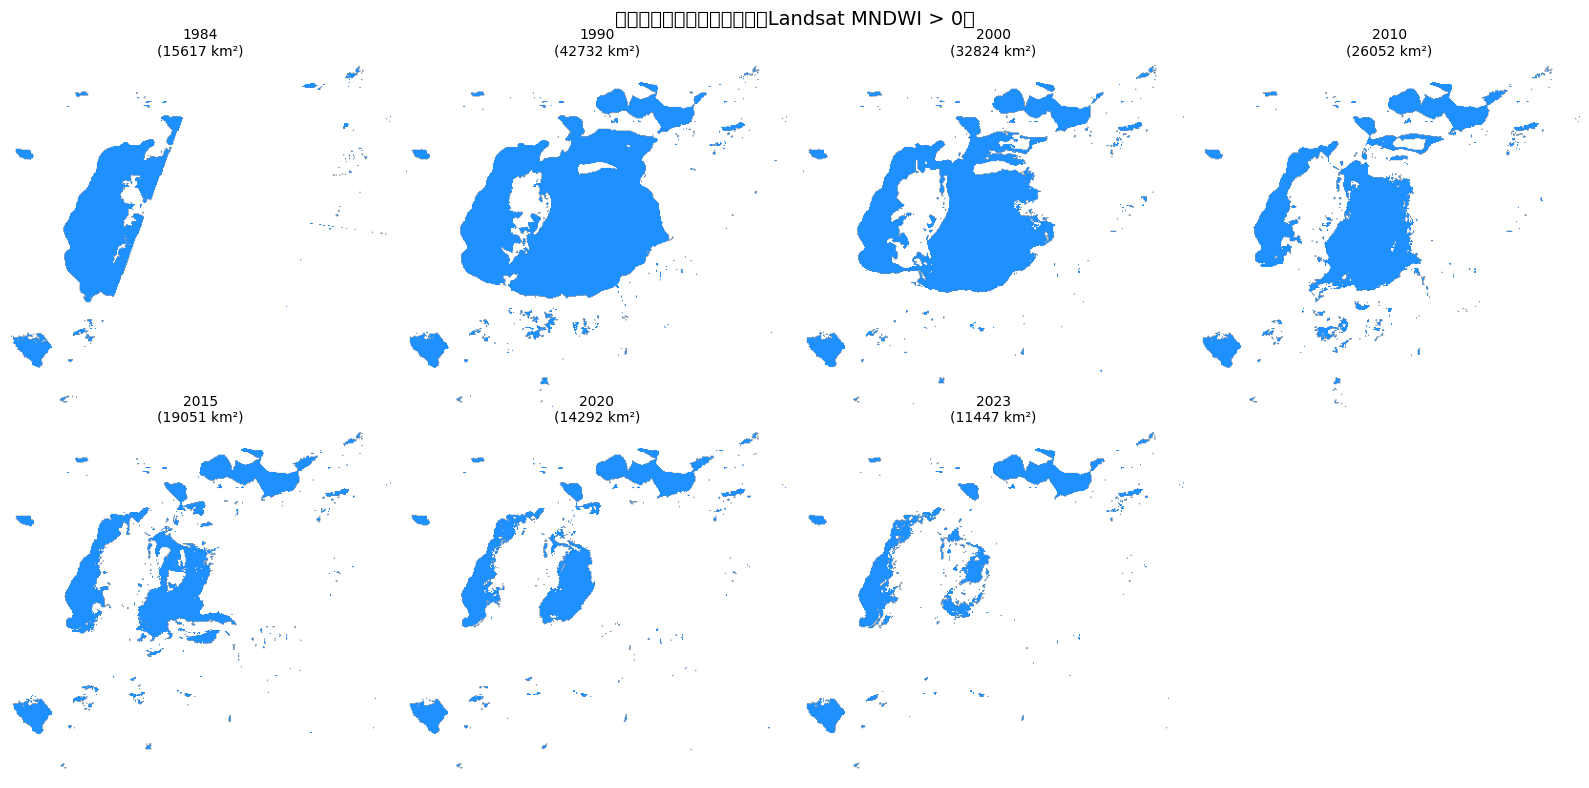

In [6]:
import requests, io

def download_water_mask_png(water_mask, year):
    """下載水體二值影像為 numpy array（快速預覽用）。"""
    url = water_mask.getThumbURL({
        'region': aral_sea_bbox,
        'dimensions': 400,
        'palette': ['white', 'dodgerblue'],
        'min': 0, 'max': 1
    })
    resp = requests.get(url)
    from PIL import Image as PILImage
    img = PILImage.open(io.BytesIO(resp.content))
    return np.array(img)


fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes_flat = axes.flatten()

for i, yr in enumerate(YEARS):
    arr = download_water_mask_png(ls_masks[yr], yr)
    axes_flat[i].imshow(arr)
    axes_flat[i].set_title(f'{yr}\n({ls_areas[yr]:.0f} km²)', fontsize=10)
    axes_flat[i].axis('off')

axes_flat[-1].axis('off')  # 隱藏最後空格
fig.suptitle('中亞鹹海代表年份水體範圍（Landsat MNDWI > 0）', fontsize=14)
plt.tight_layout()
plt.savefig('aral_sea_water_maps.png', dpi=150)
plt.show()

## 7. 縮減百分比統計

In [7]:
area_1984 = ls_areas[1984]
area_2023 = ls_areas[2023]
reduction_pct = (1 - area_2023 / area_1984) * 100

print('=== 鹹海萎縮統計 ===')
print(f'1984 年水體面積: {area_1984:.1f} km²')
print(f'2023 年水體面積: {area_2023:.1f} km²')
print(f'縮減百分比:      {reduction_pct:.1f}%')
print()
print('--- 各代表年份 ---')
for yr in YEARS:
    pct = (1 - ls_areas[yr] / area_1984) * 100
    print(f'  {yr}: {ls_areas[yr]:8.1f} km²   (相對 1984 縮減 {pct:.1f}%)')

=== 鹹海萎縮統計 ===
1984 年水體面積: 15617.4 km²
2023 年水體面積: 11447.5 km²
縮減百分比:      26.7%

--- 各代表年份 ---
  1984:  15617.4 km²   (相對 1984 縮減 0.0%)
  1990:  42731.8 km²   (相對 1984 縮減 -173.6%)
  2000:  32824.5 km²   (相對 1984 縮減 -110.2%)
  2010:  26052.4 km²   (相對 1984 縮減 -66.8%)
  2015:  19051.0 km²   (相對 1984 縮減 -22.0%)
  2020:  14292.1 km²   (相對 1984 縮減 8.5%)
  2023:  11447.5 km²   (相對 1984 縮減 26.7%)


## 8. 匯出代表年份水體影像至 Google Drive

In [8]:
for yr in [1984, 2000, 2023]:
    mndwi = get_landsat_collection(yr)
    task = ee.batch.Export.image.toDrive(
        image=mndwi.toFloat(),
        description=f'AralSea_MNDWI_{yr}',
        folder='GEE_Exports',
        fileNamePrefix=f'AralSea_MNDWI_{yr}_500m',
        region=aral_sea_bbox,
        scale=SCALE_M,
        crs=TARGET_CRS,
        maxPixels=int(1e9),
        fileFormat='GeoTIFF',
        formatOptions={'cloudOptimized': True, 'noData': -9999}
    )
    task.start()
    print(f'Task {yr} started: {task.id}')

Task 1984 started: RYIOTBKJB5D4F3D2Q2KZRXLT
Task 2000 started: CHNC3SPAIH3MWMPKFCNQ4HM2
Task 2023 started: FKRRNZATIXNBBDVUAXAH4KXE
